# CICCADA - Powerwall Telemetry Data Quality Assessment

This notebook performs a structured data quality assessment of the Tesla Powerwall fleet telemetry data (`all_data`).  
It assumes `all_data` has already been loaded as a single concatenated DataFrame with a `region` column (`ausnet`, `cpu`, `sapn`).

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

In [ ]:
# Load data
# If the combined parquet data was saved earlier, use this:
BASE = Path('../../../CICCADA - Data/Tesla/datatank_telemetry_UNSW')
all_data = pd.read_parquet(BASE / 'combined_tesla_telemetry.parquet')

'\n# Otherwise all_data should already be in memory from your loading loop.\n# Ensure timestamp is parsed and pseudonym is categorical:\nall_data[\'timestamp\'] = pd.to_datetime(all_data[\'timestamp\'])\nall_data[\'pseudonym\'] = all_data[\'pseudonym\'].astype(\'category\')\nall_data = all_data.sort_values([\'pseudonym\', \'timestamp\']).reset_index(drop=True)\n\nprint(f"Shape: {all_data.shape}")\nprint(f"Sites: {all_data[\'pseudonym\'].nunique()}")\nprint(f"Date range: {all_data[\'timestamp\'].min()} → {all_data[\'timestamp\'].max()}")\nprint(f"Memory usage: {all_data.memory_usage(deep=True).sum() / 1e6:.1f} MB")\n'

## 2. Schema & Basic Statistics

In [2]:
# Dtypes
print("=== Dtypes ===")
print(all_data.dtypes)

print("\n=== Descriptive statistics (numeric columns) ===")
all_data.describe().T

=== Dtypes ===
pseudonym                                category
timestamp                          datetime64[ns]
grid_connected_status                     float64
solar_reactive_power                      float64
battery_inverter_reactive_power           float64
battery_inverter_real_power               float64
AC_voltage                                float64
battery_target_power                      float64
solar_instant_power                       float64
solar_real_power_limit                    float64
site_energy_exported                      float64
site_energy_imported                      float64
solar_to_battery_energy                   float64
solar_to_load_energy                      float64
battery_target_reactive_power             float64
csip_opmod_exp_lim                        float64
region                                   category
csip_opmod_gen_lim_w                      float64
csip_set_grad_w                           float64
dtype: object

=== Descriptive stat

,count,mean,min,25%,50%,75%,max,std
timestamp,42749699,2025-09-18 17:44:40.570670080,2024-12-09 00:00:00,2025-06-24 04:39:00,2025-10-03 11:34:00,2025-12-20 14:58:00,2026-03-09 23:59:00,NaN
grid_connected_status,42524902.000,50.014,46.660,49.980,50.000,50.020,61.860,0.307
solar_reactive_power,42524933.000,51.554,-6368.000,0.000,0.000,0.000,12124.000,429.510
battery_inverter_reactive_power,42516400.000,-918.408,-10480.000,-1520.000,-680.000,0.000,7040.000,1081.591
battery_inverter_real_power,42516400.000,1273.126,-9880.000,120.000,400.000,1520.000,19840.000,2202.561
AC_voltage,42516398.000,240.943,0.000,238.400,241.600,244.200,279.200,6.282
battery_target_power,42516397.000,-8.771,-11480.000,30.000,160.000,440.000,21500.000,1474.847
solar_instant_power,42516400.000,1411.977,-485.000,0.000,5.000,1950.000,17095.000,2398.102
solar_real_power_limit,42479033.000,1386.421,-100.000,0.000,8.000,1998.000,8091.000,2247.560
site_energy_exported,42466681.000,2323027.703,-1.000,1301723.000,2236307.000,3210204.000,7823618.000,1318736.875


=== Global Null Summary ===
                                 null_count  null_pct
csip_opmod_gen_lim_w               42749673   100.000
csip_set_grad_w                    35017434    81.910
solar_to_load_energy               34246920    80.110
solar_to_battery_energy            34246920    80.110
csip_opmod_exp_lim                  5614330    13.130
site_energy_imported                 283018     0.660
site_energy_exported                 283018     0.660
battery_target_reactive_power        283216     0.660
solar_real_power_limit               270666     0.630
battery_inverter_real_power          233299     0.550
battery_target_power                 233302     0.550
AC_voltage                           233301     0.550
battery_inverter_reactive_power      233299     0.550
solar_instant_power                  233299     0.550
grid_connected_status                224797     0.530
solar_reactive_power                 224766     0.530
pseudonym                                 0     0.000


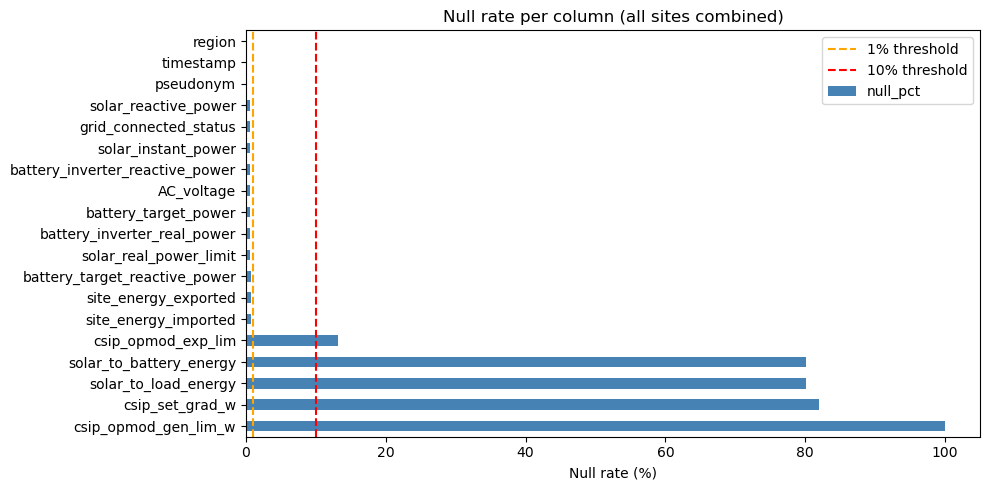

In [3]:
# Global null counts and rates
null_counts = all_data.isnull().sum()
null_rates  = (null_counts / len(all_data) * 100).round(2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_pct':   null_rates
}).sort_values('null_pct', ascending=False)

print("=== Global Null Summary ===")
print(null_summary.to_string())

# Visual
fig, ax = plt.subplots(figsize=(10, 5))
null_summary['null_pct'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Null rate (%)')
ax.set_title('Null rate per column (all sites combined)')
ax.axvline(1,  color='orange', linestyle='--', label='1% threshold')
ax.axvline(10, color='red',    linestyle='--', label='10% threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Temporal Integrity
Data is expected at exactly 1-minute (60-second) intervals per site.  
We check for: missing rows, duplicate timestamps, and non-60s gaps.

In [4]:
# Expected date range
ts_min = all_data['timestamp'].min()
ts_max = all_data['timestamp'].max()
expected_index = pd.date_range(ts_min, ts_max, freq='1min')
expected_rows_per_site = len(expected_index)
print(f"Expected rows per site (if no gaps): {expected_rows_per_site:,}")

Expected rows per site (if no gaps): 656,640


In [5]:
# Duplicate timestamps per site
dupes = (
    all_data
    .groupby('pseudonym')
    .apply(lambda g: g.duplicated(subset='timestamp').sum())
    .rename('duplicate_timestamps')
)
print("=== Duplicate timestamps per site ===")
print(dupes[dupes > 0].to_string() if (dupes > 0).any() else "No duplicates found.")

=== Duplicate timestamps per site ===
No duplicates found.


In [6]:
# Time delta distribution
# Compute per-site time deltas
all_data['dt_seconds'] = (
    all_data
    .groupby('pseudonym')['timestamp']
    .diff()
    .dt.total_seconds()
)

dt_counts = all_data['dt_seconds'].value_counts(dropna=True).head(15)
print("=== Top 15 time delta values (seconds) ===")
print(dt_counts.to_string())

# Pct of intervals that are exactly 60s
non_null_deltas = all_data['dt_seconds'].dropna()
pct_60s = (non_null_deltas == 60).mean() * 100
print(f"\nIntervals exactly 60s: {pct_60s:.2f}%")

=== Top 15 time delta values (seconds) ===
dt_seconds
60.000        42748489
120.000            767
180.000            238
7080.000            31
7140.000            26
240.000             18
300.000              8
360.000              4
480.000              2
2760.000             1
600.000              1
321180.000           1
85440.000            1
840.000              1
10620.000            1

Intervals exactly 60s: 100.00%


In [ ]:
# Per-site: actual row count vs expected, and missing row count
site_row_counts = all_data.groupby('pseudonym').size().rename('actual_rows')
site_temporal = site_row_counts.to_frame()
site_temporal['expected_rows'] = expected_rows_per_site
site_temporal['missing_rows']  = site_temporal['expected_rows'] - site_temporal['actual_rows']
site_temporal['completeness_pct'] = (site_temporal['actual_rows'] / site_temporal['expected_rows'] * 100).round(2)

print("=== Sites with <99% temporal completeness ===")
low_completeness = site_temporal[site_temporal['completeness_pct'] < 99]
print(low_completeness.sort_values('completeness_pct').to_string() if len(low_completeness) else "All sites ≥99% complete.")

# Histogram
fig, ax = plt.subplots(figsize=(10, 4))
site_temporal['completeness_pct'].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Completeness (%)')
ax.set_ylabel('Number of sites')
ax.set_title('Temporal completeness per site (1-min resolution)')
plt.tight_layout()
plt.show()

In [7]:
# Large gaps: find intervals > 60 min
large_gaps = all_data[all_data['dt_seconds'] > 3600][['pseudonym', 'timestamp', 'dt_seconds']].copy()
large_gaps['gap_hours'] = (large_gaps['dt_seconds'] / 3600).round(1)
print(f"=== Large gaps (>1 hour): {len(large_gaps)} instances across {large_gaps['pseudonym'].nunique()} sites ===")
print(large_gaps.sort_values('gap_hours', ascending=False).head(20).to_string())

=== Large gaps (>1 hour): 65 instances across 6 sites ===
         pseudonym           timestamp  dt_seconds  gap_hours
11064428     SN014 2026-02-27 08:23:00  321180.000     89.200
11064434     SN014 2026-02-28 08:17:00   85440.000     23.700
15191600     SN025 2025-10-16 02:30:00   17160.000      4.800
18643814     SN056 2025-10-14 04:20:00   11160.000      3.100
13203793     SN020 2025-09-15 02:45:00   10620.000      3.000
35578935     SN086 2025-07-07 03:43:00    8280.000      2.300
3230105      SN040 2026-03-05 08:07:00    7140.000      2.000
3230106      SN040 2026-03-05 10:05:00    7080.000      2.000
3230107      SN040 2026-03-05 12:04:00    7140.000      2.000
3230114      SN040 2026-03-06 01:53:00    7080.000      2.000
3230115      SN040 2026-03-06 03:51:00    7080.000      2.000
3230108      SN040 2026-03-05 14:02:00    7080.000      2.000
3230109      SN040 2026-03-05 16:01:00    7140.000      2.000
3230110      SN040 2026-03-05 17:59:00    7080.000      2.000
3230111     

## 4. Column-by-Column Quality Assessment

Each subsection covers one or more related columns.

In [8]:
all_data

,pseudonym,timestamp,grid_connected_status,solar_reactive_power,battery_inverter_reactive_power,battery_inverter_real_power,AC_voltage,battery_target_power,solar_instant_power,solar_real_power_limit,site_energy_exported,site_energy_imported,solar_to_battery_energy,solar_to_load_energy,battery_target_reactive_power,csip_opmod_exp_lim,region,csip_opmod_gen_lim_w,csip_set_grad_w,dt_seconds
0,SN026,2025-10-13 00:00:00,49.980,0.000,-2080.000,6680.000,245.400,-5100.000,11640.000,8091.000,727746.000,702000.000,676932.375,687775.000,0.000,NaN,ausnet,NaN,NaN,NaN
1,SN026,2025-10-13 00:01:00,49.990,0.000,-1920.000,6720.000,245.200,-5020.000,11675.000,8091.000,727829.000,702000.000,NaN,NaN,0.000,NaN,ausnet,NaN,NaN,60.000
2,SN026,2025-10-13 00:02:00,49.960,0.000,-2040.000,6800.000,245.800,-5050.000,11805.000,8091.000,727916.000,702000.000,NaN,NaN,0.000,NaN,ausnet,NaN,NaN,60.000
3,SN026,2025-10-13 00:03:00,49.970,0.000,-560.000,640.000,240.800,-4020.000,4780.000,4980.000,727996.000,702000.000,NaN,NaN,0.000,NaN,ausnet,NaN,NaN,60.000
4,SN026,2025-10-13 00:04:00,49.990,0.000,-1880.000,7040.000,244.600,-5020.000,12060.000,8091.000,728072.000,702000.000,NaN,NaN,0.000,NaN,ausnet,NaN,NaN,60.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42749694,SN100,2026-03-08 23:55:00,49.970,-4.000,-1040.000,-1160.000,242.400,-1080.000,0.000,3.000,2600703.000,2561260.000,2289154.500,1445948.125,0.000,5000.000,sapn,NaN,28.001,60.000
42749695,SN100,2026-03-08 23:56:00,49.990,11.000,-1320.000,-1280.000,243.200,-1100.000,0.000,2.000,2600722.000,2561260.000,NaN,NaN,0.000,5000.000,sapn,NaN,28.001,60.000
42749696,SN100,2026-03-08 23:57:00,49.990,-5.000,-1240.000,-1200.000,243.000,-1140.000,0.000,2.000,2600741.000,2561260.000,NaN,NaN,0.000,5000.000,sapn,NaN,28.001,60.000
42749697,SN100,2026-03-08 23:58:00,50.030,12.000,-1160.000,-1200.000,242.800,-1140.000,0.000,3.000,2600760.000,2561260.000,NaN,NaN,0.000,5000.000,sapn,NaN,28.001,60.000


### 4.1 `grid_connected_status`

**Expected (per manual - page 64, table 8):** Text — `"Grid Connected"` or `"Grid Disconnected"`  
**Observed:** Float values ~49.97 to 50.02  
**Hypothesis:** This column is potentially **grid frequency (Hz)**, mislabelled or incorrectly mapped in the data pipeline. 
The expected true grid status signal should be `grid_connected_status` (text), but what is present resembles `grid_frequency` (Hz).

dtype: float64
Null count: 224,797

Descriptive stats:
count   42524902.000
mean          50.014
std            0.307
min           46.660
25%           49.980
50%           50.000
75%           50.020
max           61.860
Name: grid_connected_status, dtype: float64

Sample unique values (first 20 sorted):
[np.float64(46.65999984741211), np.float64(46.66999816894531), np.float64(46.68000030517578), np.float64(46.689998626708984), np.float64(46.70000076293945), np.float64(46.709999084472656), np.float64(46.720001220703125), np.float64(46.72999954223633), np.float64(46.7400016784668), np.float64(46.75), np.float64(46.7599983215332), np.float64(46.77000045776367), np.float64(46.779998779296875), np.float64(46.790000915527344), np.float64(46.79999923706055), np.float64(46.810001373291016), np.float64(46.81999969482422), np.float64(46.83000183105469), np.float64(46.84000015258789), np.float64(46.849998474121094)]


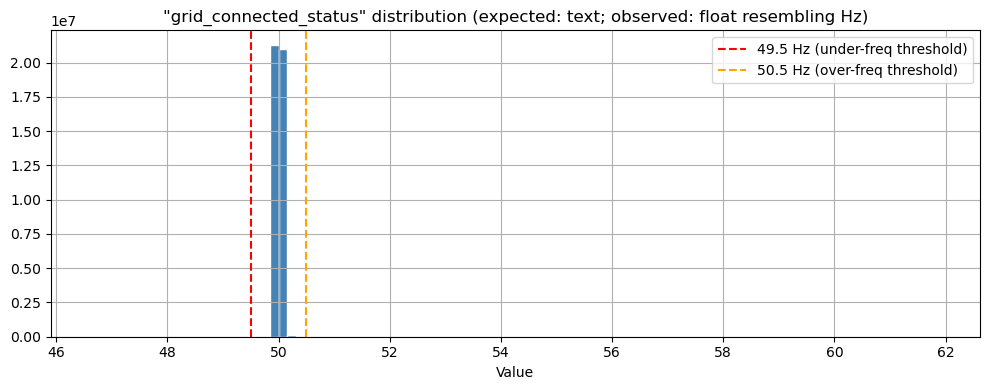


[If treated as Hz] Values <49.75 Hz: 0.009%
[If treated as Hz] Values >50.25 Hz: 0.154%
[If treated as Hz] Values <47 Hz (trip zone): 0.0004%
[If treated as Hz] Values >52 Hz (trip zone): 0.1208%


In [12]:
col = 'grid_connected_status'

print(f"dtype: {all_data[col].dtype}")
print(f"Null count: {all_data[col].isnull().sum():,}")
print(f"\nDescriptive stats:")
print(all_data[col].describe())

print(f"\nSample unique values (first 20 sorted):")
print(sorted(all_data[col].dropna().unique())[:20])

# Visualise distribution
fig, ax = plt.subplots(figsize=(10, 4))
all_data[col].dropna().hist(bins=100, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(49.5, color='red',    linestyle='--', label='49.5 Hz (under-freq threshold)')
ax.axvline(50.5, color='orange', linestyle='--', label='50.5 Hz (over-freq threshold)')
ax.set_xlabel('Value')
ax.set_title(f'"{col}" distribution (expected: text; observed: float resembling Hz)')
ax.legend()
plt.tight_layout()
plt.show()

# If it IS frequency: how often is it out of the AS/NZS 4777.2 normal operating band (49–51 Hz)?
# Check Table 4.2. from AS/NZS 4777.2:2020 (page 32)
if all_data[col].between(45, 55).mean() > 0.99:  # looks like Hz
    out_of_band = all_data[col].dropna()
    # For the below, check table 4.5. from AS/NZS 4777.2:2020 (page 34)
    pct_below = (out_of_band < 49.75).mean() * 100
    pct_above = (out_of_band > 50.25).mean() * 100
    print(f"\n[If treated as Hz] Values <49.75 Hz: {pct_below:.3f}%")
    print(f"[If treated as Hz] Values >50.25 Hz: {pct_above:.3f}%")
    print(f"[If treated as Hz] Values <47 Hz (trip zone): {(out_of_band < 47.0).mean()*100:.4f}%")
    print(f"[If treated as Hz] Values >52 Hz (trip zone): {(out_of_band > 52.0).mean()*100:.4f}%")

### 4.2 `AC_voltage`

**Expected:** AC voltage at inverter terminals (V)  
**Nominal:** 230 V (single-phase Australian standard)  
**Plausible range per AS/NZS 4777.2 (Australia A defaults):**
- **VV1 = 207 V** - lower Volt-VAr onset (reactive power supply begins)
- **VV2 = 220 V** - lower Volt-VAr deadband edge (reactive power → 0)
- **VV3 = 240 V** - upper Volt-VAr deadband edge (reactive power absorption begins)
- **VW1 = 253 V** - Volt-Watt onset (active power curtailment starts here, not 235 V)
- **VV4 = 258 V** - upper Volt-VAr onset (full reactive absorption)
- **VW2 = 260 V** - Volt-Watt ramp end (output capped at 20% of rated above here)

count   42516398.000
mean         240.943
std            6.282
min            0.000
25%          238.400
50%          241.600
75%          244.200
max          279.200
Name: AC_voltage, dtype: float64

Null count: 233,301

=== Voltage band breakdown ===
  Below 180 V (below Volt-VAr VV1 allowed range): 12,471 rows (0.029%)
  180-207 V (Volt-VAr reactive supply zone, below VV1): 269 rows (0.001%)
  207-220 V (Volt-VAr transition, VV1 to VV2): 28,660 rows (0.067%)
  220-240 V (normal/unity PF zone, VV2 to VV3): 15,449,136 rows (36.337%)
  240-253 V (Volt-VAr absorbing zone, VV3 to VW1): 27,522,807 rows (64.735%)
  253-260 V (Volt-Watt active ramp, VW1 to VW2): 175,546 rows (0.413%)
  Above 260 V (above VW2 — output capped at 20%): 292 rows (0.001%)


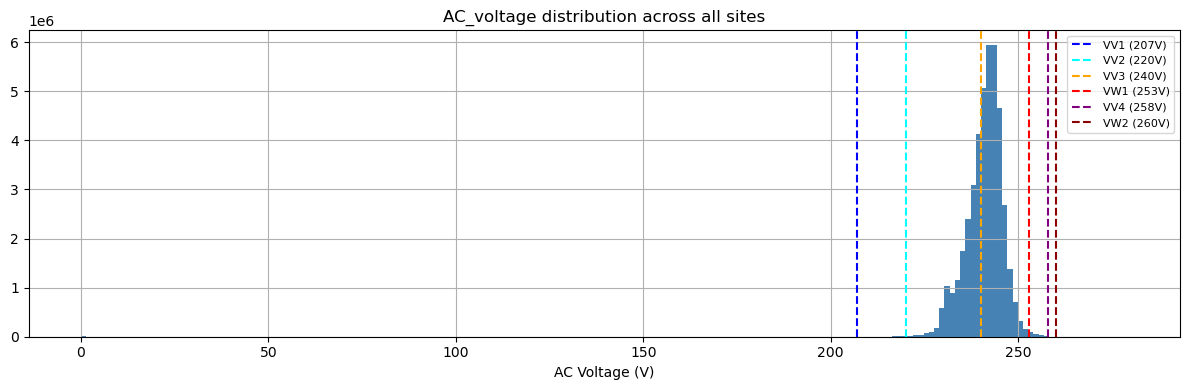


=== Sites: % time in Volt-Watt active ramp (VW1–VW2, 253–260 V) ===
pseudonym
SN008   7.152
SN054   5.614
SN073   5.342
SN066   3.923
SN081   3.297
SN014   2.974
SN061   2.453
SN099   1.113
SN015   0.988
SN004   0.719
SN046   0.461
SN057   0.337
SN100   0.213
SN037   0.187
SN051   0.167
SN080   0.156
SN063   0.131
SN049   0.104
SN055   0.103
SN092   0.049
SN034   0.045
SN088   0.033
SN005   0.023
SN078   0.020
SN069   0.016
SN097   0.013
SN007   0.011
SN032   0.010
SN019   0.010
SN074   0.009
SN043   0.007
SN067   0.005
SN001   0.005
SN089   0.003
SN042   0.003
SN056   0.002
SN086   0.002
SN033   0.001
SN052   0.001
SN053   0.001
SN087   0.001
SN011   0.000
SN035   0.000
SN028   0.000
SN070   0.000
SN021   0.000
SN012   0.000
SN003   0.000
SN083   0.000
SN079   0.000
SN030   0.000
SN029   0.000
SN010   0.000
SN009   0.000
SN002   0.000
SN031   0.000
SN024   0.000
SN025   0.000
SN026   0.000
SN027   0.000
SN022   0.000
SN023   0.000
SN006   0.000
SN013   0.000
SN016   0.000
SN017   0.0

In [23]:
col = 'AC_voltage'

print(all_data[col].describe())
print(f"\nNull count: {all_data[col].isnull().sum():,}")

v = all_data[col].dropna()

# Threshold analysis (using Australia A for now)
thresholds = [
    (v < 180,            'Below 180 V (below Volt-VAr VV1 allowed range)'),
    (v.between(180, 207), '180-207 V (Volt-VAr reactive supply zone, below VV1)'),
    (v.between(207, 220), '207-220 V (Volt-VAr transition, VV1 to VV2)'),
    (v.between(220, 240), '220-240 V (normal/unity PF zone, VV2 to VV3)'),
    (v.between(240, 253), '240-253 V (Volt-VAr absorbing zone, VV3 to VW1)'),
    (v.between(253, 260), '253-260 V (Volt-Watt active ramp, VW1 to VW2)'),
    (v > 260,            'Above 260 V (above VW2 — output capped at 20%)'),
]
print("\n=== Voltage band breakdown ===")
for mask, label in thresholds:
    print(f"  {label}: {mask.sum():,} rows ({mask.mean()*100:.3f}%)")

# Distribution
fig, ax = plt.subplots(figsize=(12, 4))
v.hist(bins=200, ax=ax, color='steelblue', edgecolor='none')
for xval, label, colour in [
    (207, 'VV1 (207V)',  'blue'),
    (220, 'VV2 (220V)',  'cyan'),
    (240, 'VV3 (240V)',  'orange'),
    (253, 'VW1 (253V)',  'red'),
    (258, 'VV4 (258V)',  'purple'),
    (260, 'VW2 (260V)',  'darkred'),
]:
    ax.axvline(xval, linestyle='--', color=colour, label=label)
ax.set_xlabel('AC Voltage (V)')
ax.set_title('AC_voltage distribution across all sites')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Per-site: % of time in Volt-Watt zone
voltwatt_pct = (
    all_data.dropna(subset=[col])
    .groupby('pseudonym')[col]
    .apply(lambda x: x.between(253, 260).mean() * 100)
    .rename('pct_time_voltwatt_zone')
    .sort_values(ascending=False)
)
print("\n=== Sites: % time in Volt-Watt active ramp (VW1–VW2, 253–260 V) ===")
print(voltwatt_pct.to_string())

In [24]:
# Frozen/stuck voltage detection (same value for ≥5 consecutive minutes)
all_data['voltage_frozen'] = (
    all_data.groupby('pseudonym')[col]
    .transform(lambda x: (x.diff() == 0).rolling(5, min_periods=5).sum() == 5)
)
frozen_pct = all_data['voltage_frozen'].mean() * 100
frozen_by_site = all_data.groupby('pseudonym')['voltage_frozen'].mean().sort_values(ascending=False) * 100
print(f"Overall frozen voltage rate: {frozen_pct:.3f}%")
print("\nTop 10 sites by frozen voltage rate (%)")
print(frozen_by_site.head(10).to_string())

Overall frozen voltage rate: 0.049%

Top 10 sites by frozen voltage rate (%)
pseudonym
SN087   0.845
SN047   0.715
SN031   0.362
SN093   0.278
SN056   0.142
SN070   0.122
SN092   0.120
SN062   0.112
SN055   0.108
SN096   0.100


### 4.3 `solar_instant_power`

**Expected:** Instantaneous solar real power (W), should be ≥0 (generation only).  
**Quality checks:** negative values, nighttime solar, implausibly high values, nulls.

count   42516400.000
mean        1411.977
std         2398.102
min         -485.000
25%            0.000
50%            5.000
75%         1950.000
max        17095.000
Name: solar_instant_power, dtype: float64

Null count: 233,299

Values < -250W (manual 'Negative Solar' diagnostic threshold): 2 (0.000%)
Values < 0W (any negative): 910,648 (2.142%)

Sites with >1% negative solar (would fail Powerhub diagnostic):
None


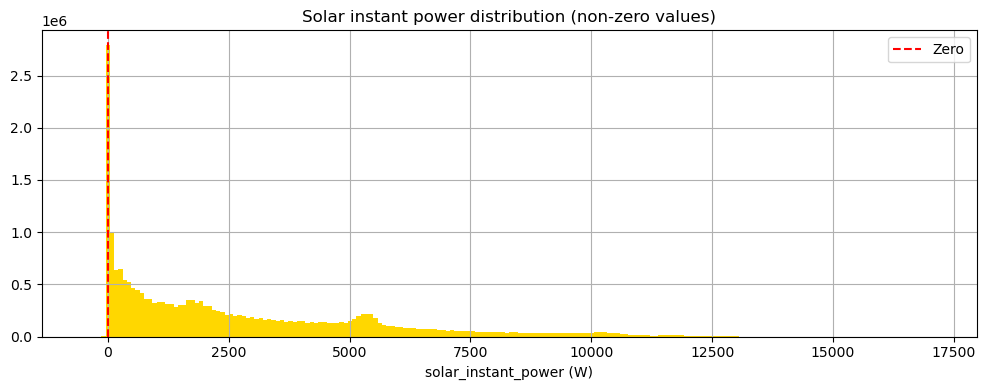

In [18]:
col = 'solar_instant_power'
print(all_data[col].describe())
print(f"\nNull count: {all_data[col].isnull().sum():,}")

s = all_data[col].dropna()

# Negative values (metering error per manual: fails if solar < -250W > 1% of time)
neg_mask = s < -250
print(f"\nValues < -250W (manual 'Negative Solar' diagnostic threshold): {neg_mask.sum():,} ({neg_mask.mean()*100:.3f}%)")

# Any negative at all
any_neg = s < 0
print(f"Values < 0W (any negative): {any_neg.sum():,} ({any_neg.mean()*100:.3f}%)")

# Per-site negative solar rate
neg_by_site = (
    all_data.dropna(subset=[col])
    .groupby('pseudonym')[col]
    .apply(lambda x: (x < -250).mean() * 100)
    .rename('pct_negative_solar')
    .sort_values(ascending=False)
)
print("\nSites with >1% negative solar (would fail Powerhub diagnostic):")
failing = neg_by_site[neg_by_site > 1]
print(failing.to_string() if len(failing) else "None")

# Distribution (excluding zeros for clarity)
fig, ax = plt.subplots(figsize=(10, 4))
s[s != 0].hist(bins=200, ax=ax, color='gold', edgecolor='none')
ax.axvline(0, color='red', linestyle='--', label='Zero')
ax.set_xlabel('solar_instant_power (W)')
ax.set_title('Solar instant power distribution (non-zero values)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 `solar_real_power_limit`

**Expected:** Maximum allowed solar output (W). This potentially is the **curtailment ceiling**.  
When `solar_instant_power < solar_real_power_limit`, the inverter is operating below capacity.  
When they are approximately equal, the inverter is being curtailed.  
High null rate (~80% in SN026). 
Important to understand whether nulls mean 'no limit active' or 'data unavailable'.

count   42479033.000
mean        1386.421
std         2247.560
min         -100.000
25%            0.000
50%            8.000
75%         1998.000
max         8091.000
Name: solar_real_power_limit, dtype: float64

Null count: 270,666 (0.6%)

=== Null rate distribution across sites ===
count   100.000
mean      1.125
std       5.774
min       0.001
25%       0.012
50%       0.081
75%       0.233
max      52.458
Name: pct_null, dtype: float64


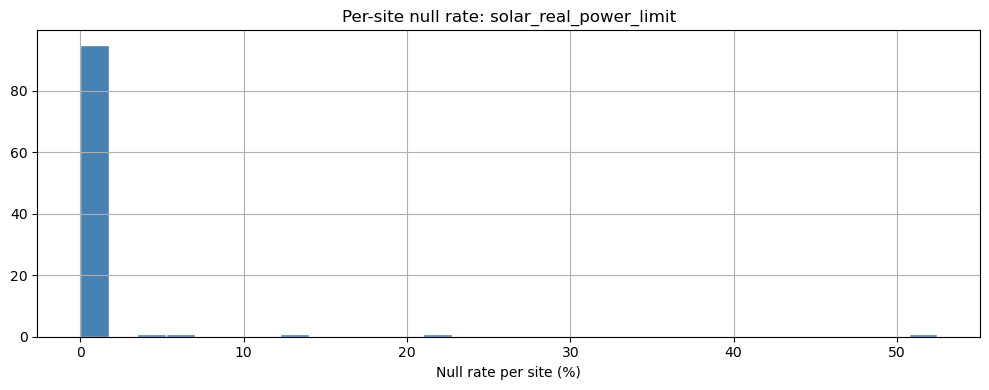


Non-null values that are exactly 0W (full curtailment): 4,400,744 (10.36%)

Rows where solar_instant_power ≈ solar_real_power_limit (within 50W): 33,687,653 (79.31% of rows with both values present)


In [21]:
col = 'solar_real_power_limit'
print(all_data[col].describe())
print(f"\nNull count: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.1f}%)")

# Null rate per site
null_by_site = (
    all_data.groupby('pseudonym')[col]
    .apply(lambda x: x.isnull().mean() * 100)
    .rename('pct_null')
)
print("\n=== Null rate distribution across sites ===")
print(null_by_site.describe())

fig, ax = plt.subplots(figsize=(10, 4))
null_by_site.hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Null rate per site (%)')
ax.set_title(f'Per-site null rate: {col}')
plt.tight_layout()
plt.show()

# When non-null: does it equal zero? (zero limit = full curtailment command)
non_null = all_data[col].dropna()
print(f"\nNon-null values that are exactly 0W (full curtailment): {(non_null == 0).sum():,} ({(non_null == 0).mean()*100:.2f}%)")

# Curtailment proxy: rows where solar_instant_power >= solar_real_power_limit - 50W
# (i.e. actively hitting the limit)
both_present = all_data.dropna(subset=[col, 'solar_instant_power'])
curtailed = (both_present['solar_instant_power'] >= both_present[col] - 50)
print(f"\nRows where solar_instant_power ≈ solar_real_power_limit (within 50W): {curtailed.sum():,} ({curtailed.mean()*100:.2f}% of rows with both values present)")

### 4.5 `battery_inverter_real_power` and `battery_target_power`

**Sign convention (per manual):** Positive = discharge, Negative = charge  
**Quality checks:** nulls, plausibility, how closely does actual power track the target command?


=== battery_inverter_real_power ===
count   42516400.000
mean        1273.126
std         2202.561
min        -9880.000
25%          120.000
50%          400.000
75%         1520.000
max        19840.000
Name: battery_inverter_real_power, dtype: float64
Null: 233,299 (0.55%)
Charging (< 0): 1,927,294 (4.5%)
Discharging (> 0): 36,038,271 (84.8%)
Idle (== 0): 4,550,835 (10.7%)

=== battery_target_power ===
count   42516397.000
mean          -8.771
std         1474.847
min       -11480.000
25%           30.000
50%          160.000
75%          440.000
max        21500.000
Name: battery_target_power, dtype: float64
Null: 233,302 (0.55%)
Charging (< 0): 9,891,584 (23.3%)
Discharging (> 0): 32,518,328 (76.5%)
Idle (== 0): 106,485 (0.3%)

=== Tracking error (actual - target) ===
count   42516357.000
mean        1281.896
std         2410.504
min        -8520.000
25%         -140.000
50%          -40.000
75%         1820.000
max        16800.000
Name: tracking_error, dtype: float64


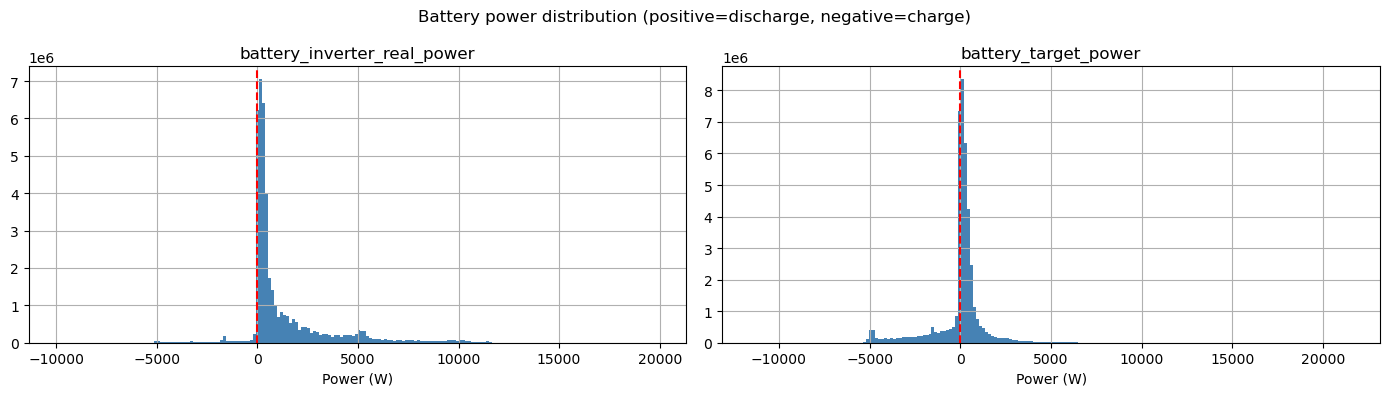

In [ ]:
# See powerhub manual page 67 for battery_inverter_real_power, and page 62 for battery_target_power.

for col in ['battery_inverter_real_power', 'battery_target_power']:
    s = all_data[col].dropna()
    print(f"\n=== {col} ===")
    print(s.describe())
    print(f"Null: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
    print(f"Charging (< 0): {(s < 0).sum():,} ({(s < 0).mean()*100:.1f}%)")
    print(f"Discharging (> 0): {(s > 0).sum():,} ({(s > 0).mean()*100:.1f}%)")
    print(f"Idle (== 0): {(s == 0).sum():,} ({(s == 0).mean()*100:.1f}%)")

# Tracking error: actual vs target
both = all_data.dropna(subset=['battery_inverter_real_power', 'battery_target_power'])
both = both.assign(
    tracking_error = both['battery_inverter_real_power'] - both['battery_target_power']
)
print("\n=== Tracking error (actual - target) ===")
print(both['tracking_error'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['battery_inverter_real_power', 'battery_target_power']):
    all_data[col].dropna().hist(bins=200, ax=ax, color='steelblue', edgecolor='none')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Power (W)')
    ax.set_title(col)
plt.suptitle('Battery power distribution (positive=discharge, negative=charge)')
plt.tight_layout()
plt.show()

### 4.6 `solar_reactive_power` and `battery_inverter_reactive_power`

**Expected:** Instantaneous reactive power (VAr)  
**Quality checks:** nulls, range (AS/NZS 4777.2 Volt-VAr response curves bound reactive power to ±60% of rated apparent power)


=== solar_reactive_power ===
count   42524933.000
mean          51.554
std          429.510
min        -6368.000
25%            0.000
50%            0.000
75%            0.000
max        12124.000
Name: solar_reactive_power, dtype: float64
Null: 224,766 (0.53%)

=== battery_inverter_reactive_power ===
count   42516400.000
mean        -918.408
std         1081.591
min       -10480.000
25%        -1520.000
50%         -680.000
75%            0.000
max         7040.000
Name: battery_inverter_reactive_power, dtype: float64
Null: 233,299 (0.55%)


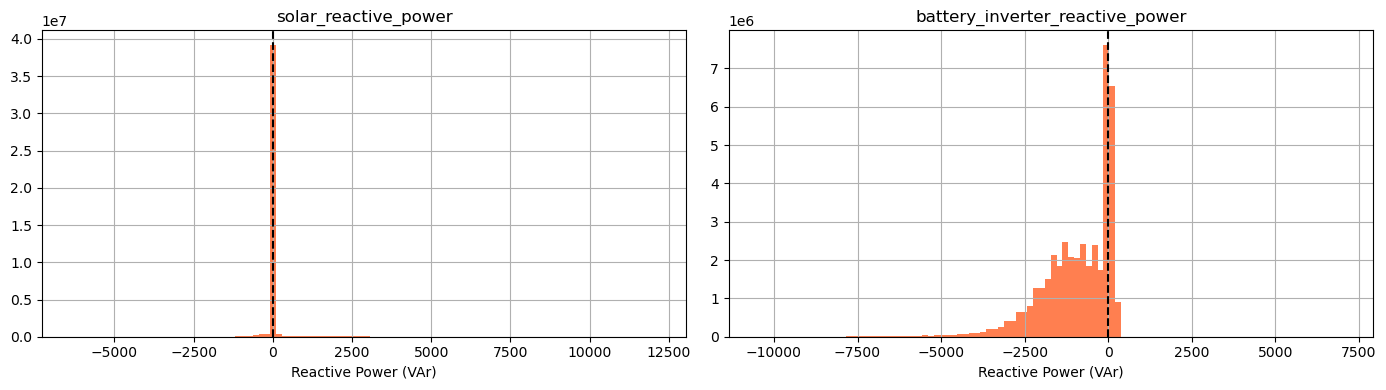

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['solar_reactive_power', 'battery_inverter_reactive_power']):
    s = all_data[col].dropna()
    s.hist(bins=100, ax=ax, color='coral', edgecolor='none')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_xlabel('Reactive Power (VAr)')
    ax.set_title(col)
    print(f"\n=== {col} ===")
    print(s.describe())
    print(f"Null: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
plt.tight_layout()
plt.show()

### 4.7 `site_energy_exported` and `site_energy_imported`

**Expected:** Cumulative energy (Wh). These seem to be **running totals** (odometer-style), not interval energy.

**Quality checks:** non-monotonic (counter rollover or reset), negative values, nulls, implausible jumps.

<Axes: xlabel='timestamp'>

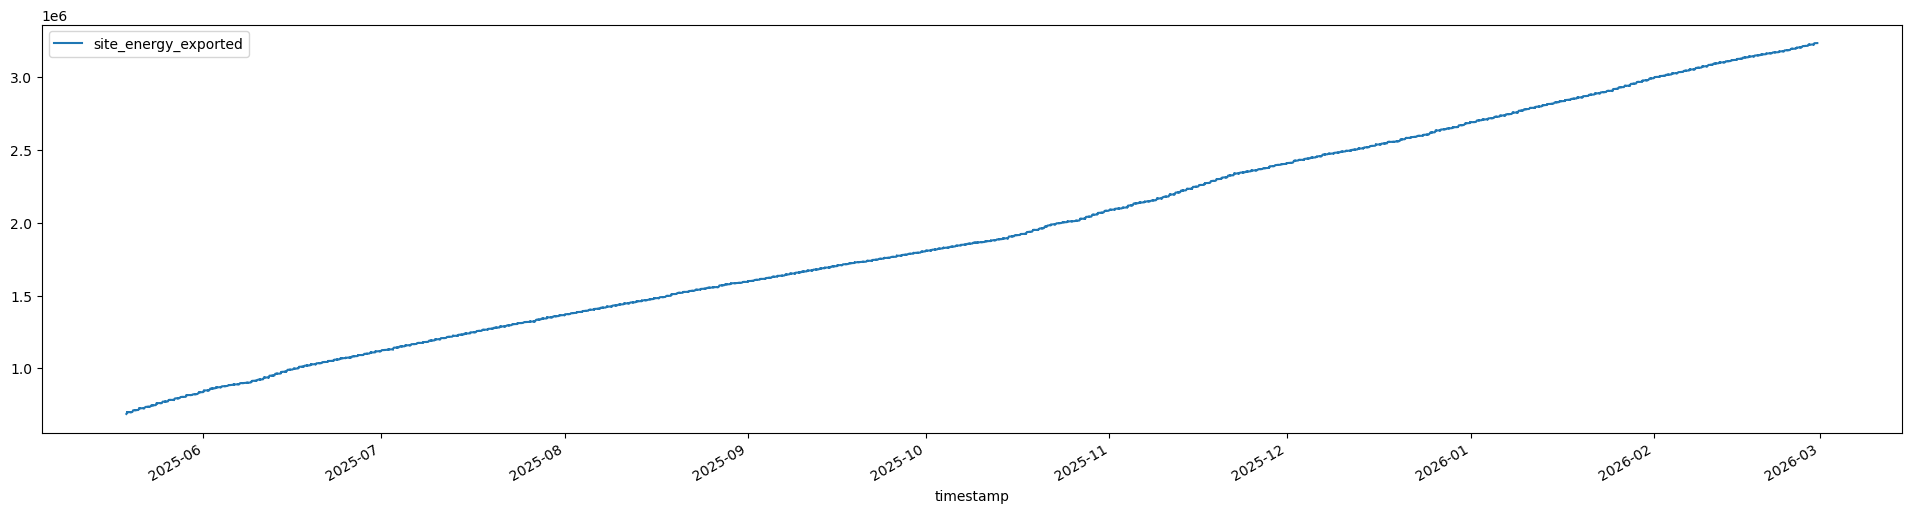

In [34]:
all_data[all_data['pseudonym'] == 'SN005'].plot(x='timestamp', y='site_energy_exported', figsize=(24,6))

In [ ]:
for col in ['site_energy_exported', 'site_energy_imported']:
    print(f"\n=== {col} ===")
    print(all_data[col].describe())
    print(f"Null: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
    print(f"Negative values: {(all_data[col] < 0).sum():,}")

    # Non-monotonic check: per-site, compute diffs.
    # Negative diff = counter reset or error
    diffs = (
        all_data.dropna(subset=[col])
        .groupby('pseudonym')[col]
        .diff()
    )
    n_decreases = (diffs < -100).sum()  # allow small floating point noise
    n_big_jumps = (diffs > 1e6).sum()   # >1 MWh in one minute = likely error
    print(f"Non-monotonic drops (diff < -100 Wh): {n_decreases:,}")
    print(f"Implausible jumps (diff > 1 MWh/min): {n_big_jumps:,}")


=== site_energy_exported ===
count   42466681.000
mean     2323027.703
std      1318736.875
min           -1.000
25%      1301723.000
50%      2236307.000
75%      3210204.000
max      7823618.000
Name: site_energy_exported, dtype: float64
Null: 283,018 (0.66%)
Negative values: 7
Non-monotonic drops (diff < -100 Wh): 290
Implausible jumps (diff > 1 MWh/min): 149

=== site_energy_imported ===
count   42466681.000
mean     2264068.740
std      1285017.315
min           -1.000
25%      1269791.000
50%      2181565.000
75%      3129953.000
max      7601734.000
Name: site_energy_imported, dtype: float64
Null: 283,018 (0.66%)
Negative values: 7
Non-monotonic drops (diff < -100 Wh): 353
Implausible jumps (diff > 1 MWh/min): 147


### 4.8 `solar_to_battery_energy` and `solar_to_load_energy`

**Expected:** Energy flows (Wh). Should be ≥ 0  

In [35]:
for col in ['solar_to_battery_energy', 'solar_to_load_energy']:
    print(f"\n=== {col} ===")
    null_by_site = all_data.groupby('pseudonym')[col].apply(lambda x: x.isnull().mean() * 100)
    print(f"Overall null rate: {all_data[col].isnull().mean()*100:.1f}%")
    print(f"Sites with 100% nulls: {(null_by_site == 100).sum()}")
    print(f"Sites with 0% nulls:   {(null_by_site == 0).sum()}")
    print(f"Sites with partial nulls: {((null_by_site > 0) & (null_by_site < 100)).sum()}")

    non_null = all_data[col].dropna()
    if len(non_null):
        print(f"Non-null describe:")
        print(non_null.describe())
        print(f"Negative values: {(non_null < 0).sum():,}")

# Are the sites with data clustered by region?
print("\n=== solar_to_battery_energy: null rate by region ===")
if 'region' in all_data.columns:
    print(all_data.groupby('region')['solar_to_battery_energy'].apply(lambda x: x.isnull().mean() * 100).rename('null_pct'))


=== solar_to_battery_energy ===
Overall null rate: 80.1%
Sites with 100% nulls: 0
Sites with 0% nulls:   0
Sites with partial nulls: 100
Non-null describe:
count    8502779.000
mean     2199555.037
std      1328611.906
min            0.000
25%      1226364.438
50%      2056190.250
75%      2984032.000
max     10746548.000
Name: solar_to_battery_energy, dtype: float64
Negative values: 0

=== solar_to_load_energy ===
Overall null rate: 80.1%
Sites with 100% nulls: 0
Sites with 0% nulls:   0
Sites with partial nulls: 100
Non-null describe:
count    8502779.000
mean     2190146.751
std      1968142.704
min            0.000
25%       973009.938
50%      1697889.750
75%      2855882.000
max     19250506.000
Name: solar_to_load_energy, dtype: float64
Negative values: 0

=== solar_to_battery_energy: null rate by region ===
region
ausnet   80.102
cpu      79.998
sapn     80.153
Name: null_pct, dtype: float64


### 4.9 `battery_target_reactive_power`

**Expected:** Reactive power command from Site Controller (VAr)  
**Quality checks:** nulls, whether it is ever non-zero (active Volt-VAr dispatch)

In [36]:
col = 'battery_target_reactive_power'
print(all_data[col].describe())
print(f"Null: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
print(f"Exactly zero: {(all_data[col] == 0).sum():,} ({(all_data[col] == 0).mean()*100:.2f}%)")
nonzero = all_data[col].dropna()
nonzero = nonzero[nonzero != 0]
print(f"Non-zero values: {len(nonzero):,}")
if len(nonzero):
    print(nonzero.describe())

count   42466483.000
mean          -4.823
std          121.043
min       -12010.964
25%            0.000
50%            0.000
75%            0.000
max         1343.701
Name: battery_target_reactive_power, dtype: float64
Null: 283,216 (0.66%)
Exactly zero: 42,347,249 (99.06%)
Non-zero values: 119,234
count   119234.000
mean     -1717.676
std       1508.684
min     -12010.964
25%      -2195.172
50%      -1617.136
75%       -658.867
max       1343.701
Name: battery_target_reactive_power, dtype: float64


### 4.10 `csip_opmod_exp_lim`

**Expected:** CSIP-AUS export limit (W) active on this site.
This is the export limit dispatched via the Common Smart Inverter Profile (Australia).  
When non-null and non-zero, an export limit is active.  
When zero, full curtailment has been commanded.  
**When null:** the CSIP-AUS connection may not be active, or the field was not transmitted.
**Note:** Can't find this parameter in the powerhub manual

count   37135369.000
mean        6988.787
std         4838.779
min            0.000
25%         4500.000
50%         7000.000
75%        10000.000
max        30000.000
Name: csip_opmod_exp_lim, dtype: float64

Null: 5,614,330 (13.13%)
Zero (full curtailment commanded): 4,493,856

Value counts (top 20):
csip_opmod_exp_lim
10000.000    15993876
5000.000      8996506
0.000         4493856
1500.000      3103828
15000.000     1458247
4500.000       866969
1000.000       584617
20000.000      394280
30000.000      338195
11100.000      178524
7000.000       155858
3500.000       149607
2500.000       132034
8000.000        21933
6000.000         2630
24000.000        1301
3000.000         1226
12000.000        1020
4000.000          708
16000.000         695

=== Null rate distribution across sites ===
count   100.000
mean     12.289
std      15.841
min       0.007
25%       2.728
50%       8.763
75%      16.781
max     100.000
Name: null_pct, dtype: float64


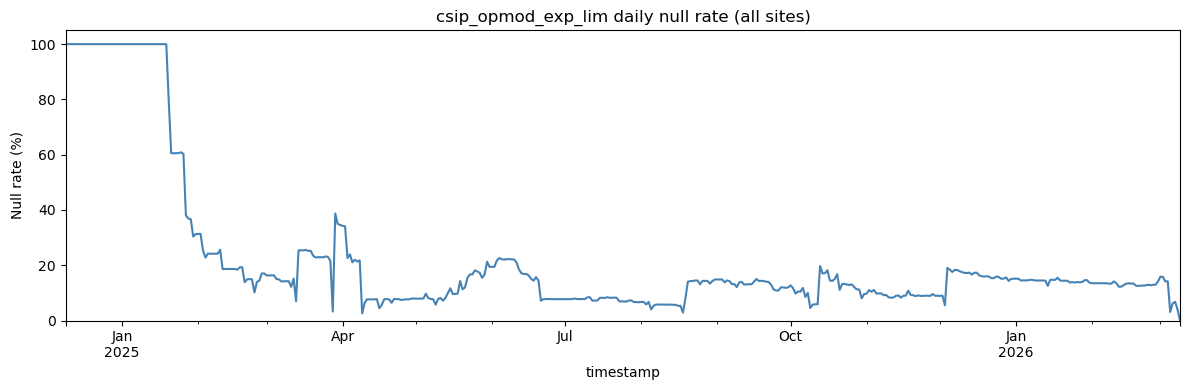


Active export limits (>0W): 32,641,513 rows
count   32641513.000
mean        7950.954
std         4357.417
min         1000.000
25%         5000.000
50%        10000.000
75%        10000.000
max        30000.000
Name: csip_opmod_exp_lim, dtype: float64


In [39]:
col = 'csip_opmod_exp_lim'
print(all_data[col].describe())
print(f"\nNull: {all_data[col].isnull().sum():,} ({all_data[col].isnull().mean()*100:.2f}%)")
print(f"Zero (full curtailment commanded): {(all_data[col] == 0).sum():,}")

non_null = all_data[col].dropna()
print(f"\nValue counts (top 20):")
print(non_null.value_counts().head(20).to_string())

# Null rate per site
null_by_site = all_data.groupby('pseudonym')[col].apply(lambda x: x.isnull().mean() * 100).rename('null_pct')
print("\n=== Null rate distribution across sites ===")
print(null_by_site.describe())

# Are nulls clustered in time? (suggests CSIP not yet deployed at start of dataset)
all_data['csip_null'] = all_data[col].isnull()
csip_null_over_time = (
    all_data.set_index('timestamp')
    .resample('1D')['csip_null']
    .mean() * 100
)
fig, ax = plt.subplots(figsize=(12, 4))
csip_null_over_time.plot(ax=ax, color='steelblue')
ax.set_ylabel('Null rate (%)')
ax.set_title('csip_opmod_exp_lim daily null rate (all sites)')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

# When non-null and > 0: distribution of limit values
active_limits = non_null[non_null > 0]
if len(active_limits):
    print(f"\nActive export limits (>0W): {len(active_limits):,} rows")
    print(active_limits.describe())

## 5. Cross-Column Physical Plausibility
These checks test whether combinations of columns make physical sense.

In [38]:
# Check 1: Battery discharging AND exporting > limit
# If csip_opmod_exp_lim is active, site_energy_exported shouldn't be growing
# faster than the limit permits. This is a rough proxy — exact check needs
# interval energy, not cumulative.
# Here we flag rows where battery is discharging (>0) and csip limit is 0
# (should mean no export allowed).
check1 = all_data[
    (all_data['battery_inverter_real_power'] > 100) &  # battery discharging
    (all_data['csip_opmod_exp_lim'] == 0)              # zero export limit active
]
print(f"Check 1 — Battery discharging while CSIP export limit = 0: {len(check1):,} rows ({len(check1)/len(all_data)*100:.2f}%)")
# Note: this isn't necessarily wrong (battery could be serving load, not exporting)
# but worth reviewing.

Check 1 — Battery discharging while CSIP export limit = 0: 2,852,266 rows (6.67%)


In [40]:
# Check 2: Solar exceeds its own limit
# solar_instant_power should not significantly exceed solar_real_power_limit
both = all_data.dropna(subset=['solar_instant_power', 'solar_real_power_limit'])
over_limit = both[both['solar_instant_power'] > both['solar_real_power_limit'] + 100]  # 100W tolerance
print(f"Check 2 — solar_instant_power > solar_real_power_limit + 100W: {len(over_limit):,} rows ({len(over_limit)/len(both)*100:.2f}% of rows with both present)")
if len(over_limit):
    print("Example rows:")
    print(over_limit[['pseudonym', 'timestamp', 'solar_instant_power', 'solar_real_power_limit']].head(10).to_string())

Check 2 — solar_instant_power > solar_real_power_limit + 100W: 2,007,154 rows (4.73% of rows with both present)
Example rows:
    pseudonym           timestamp  solar_instant_power  solar_real_power_limit
0       SN026 2025-10-13 00:00:00            11640.000                8091.000
1       SN026 2025-10-13 00:01:00            11675.000                8091.000
2       SN026 2025-10-13 00:02:00            11805.000                8091.000
4       SN026 2025-10-13 00:04:00            12060.000                8091.000
7       SN026 2025-10-13 00:07:00            10080.000                8091.000
9       SN026 2025-10-13 00:09:00            10120.000                8091.000
11      SN026 2025-10-13 00:11:00            11230.000                8091.000
115     SN026 2025-10-13 01:55:00             3635.000                3453.000
117     SN026 2025-10-13 01:57:00             6800.000                5996.000
121     SN026 2025-10-13 02:01:00             4615.000                4494.000


In [42]:
# Check 3: Negative home load proxy
# The Powerhub diagnostic 'Negative Home Load' fires if:
# load_real_power < -100W more than 1% of the time.
# We don't have load_real_power directly, but we can approximate:
# Approx load = solar - battery_discharge + grid_import
# (This is only possible if the sign convention is consistent)
# For now, flag if solar_to_load_energy goes negative
neg_stl = all_data[all_data['solar_to_load_energy'] < 0]
print(f"Check 3 - solar_to_load_energy < 0: {len(neg_stl):,} rows")

Check 3 - solar_to_load_energy < 0: 0 rows


In [43]:
# Check 4: Target vs actual reactive power consistency
# Reactive power target is almost always 0 — flag sites where
# actual battery_inverter_reactive_power is large when target is 0
both_rp = all_data.dropna(subset=['battery_inverter_reactive_power', 'battery_target_reactive_power'])
unexpected_reactive = both_rp[
    (both_rp['battery_target_reactive_power'] == 0) &
    (both_rp['battery_inverter_reactive_power'].abs() > 500)
]
print(f"Check 4 — Large reactive power when target is 0 (>500 VAr): {len(unexpected_reactive):,} rows")
if len(unexpected_reactive):
    print(unexpected_reactive.groupby('pseudonym').size().sort_values(ascending=False).head(10))

Check 4 — Large reactive power when target is 0 (>500 VAr): 23,194,898 rows
pseudonym
SN079    554616
SN072    534041
SN051    528679
SN052    524543
SN074    521550
SN092    520947
SN070    520079
SN077    515934
SN088    496167
SN087    495851
dtype: int64


## 6. Per-Site Quality Summary

All quality dimensions into a single per-site summary table.

In [45]:
numeric_cols = [
    'grid_connected_status', 'solar_reactive_power', 'battery_inverter_reactive_power',
    'battery_inverter_real_power', 'AC_voltage', 'battery_target_power',
    'solar_instant_power', 'solar_real_power_limit', 'site_energy_exported',
    'site_energy_imported', 'solar_to_battery_energy', 'solar_to_load_energy',
    'battery_target_reactive_power', 'csip_opmod_exp_lim'
]

def site_quality(g):
    n = len(g)
    row = {}
    row['n_rows'] = n
    row['completeness_pct'] = round(n / expected_rows_per_site * 100, 2)
    row['duplicate_ts'] = g.duplicated(subset='timestamp').sum()
    row['n_large_gaps'] = (g['dt_seconds'] > 3600).sum()

    for col in numeric_cols:
        null_rate = g[col].isnull().mean() * 100
        row[f'{col}_null_pct'] = round(null_rate, 1)

    # Key derived flags
# REPLACE WITH
    row['pct_voltwatt_zone']   = round(g['AC_voltage'].between(253, 260).mean() * 100, 2)  # VW1-VW2 ramp
    row['pct_above_VW1']       = round((g['AC_voltage'] > 253).mean() * 100, 2)            # any VW exposure
    row['pct_above_VW2']       = round((g['AC_voltage'] > 260).mean() * 100, 2)            
    row['pct_negative_solar']  = round((g['solar_instant_power'] < -250).mean() * 100, 3)
    row['csip_active_rows']    = (g['csip_opmod_exp_lim'].notna() & (g['csip_opmod_exp_lim'] >= 0)).sum()
    row['csip_zero_limit_rows'] = (g['csip_opmod_exp_lim'] == 0).sum()

    return pd.Series(row)

print("Computing per-site quality summary...")
site_quality_df = all_data.groupby('pseudonym').apply(site_quality)

if 'region' in all_data.columns:
    site_quality_df = site_quality_df.join(
        all_data.groupby('pseudonym')['region'].first()
    )

print("Done.")
print(f"\nQuality summary shape: {site_quality_df.shape}")
site_quality_df

Computing per-site quality summary...
Done.

Quality summary shape: (100, 25)


,n_rows,completeness_pct,duplicate_ts,n_large_gaps,grid_connected_status_null_pct,solar_reactive_power_null_pct,battery_inverter_reactive_power_null_pct,battery_inverter_real_power_null_pct,AC_voltage_null_pct,battery_target_power_null_pct,solar_instant_power_null_pct,solar_real_power_limit_null_pct,site_energy_exported_null_pct,site_energy_imported_null_pct,solar_to_battery_energy_null_pct,solar_to_load_energy_null_pct,battery_target_reactive_power_null_pct,csip_opmod_exp_lim_null_pct,pct_voltwatt_zone,pct_above_VW1,pct_above_VW2,pct_negative_solar,csip_active_rows,csip_zero_limit_rows,region
pseudonym,,,,,,,,,,,,,,,,,,,,,,,,,
SN001,431313.000,65.680,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,80.000,80.000,0.100,0.400,0.000,0.000,0.000,0.000,429598.000,147216.000,cpu
SN002,418371.000,63.710,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,80.000,80.000,0.100,4.200,0.000,0.000,0.000,0.000,400847.000,95743.000,cpu
SN003,416894.000,63.490,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,80.000,80.000,0.100,0.400,0.000,0.000,0.000,0.000,415361.000,280938.000,cpu
SN004,411171.000,62.620,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,80.000,80.000,0.100,27.400,0.720,0.630,0.000,0.000,298323.000,119764.000,cpu
SN005,411177.000,62.620,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,80.000,80.000,0.100,8.100,0.020,0.020,0.000,0.000,377851.000,56041.000,cpu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SN096,544301.000,82.890,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.200,0.100,0.100,80.000,80.000,0.100,10.200,0.000,0.000,0.000,0.000,488858.000,40.000,sapn
SN097,544306.000,82.890,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.100,0.100,80.000,80.000,0.100,18.200,0.010,0.010,0.000,0.000,445468.000,40.000,sapn
SN098,71892.000,10.950,0.000,0.000,0.000,0.000,52.500,52.500,52.500,52.500,52.500,52.500,0.100,0.100,80.000,80.000,0.100,12.300,0.000,0.000,0.000,0.000,63077.000,0.000,sapn


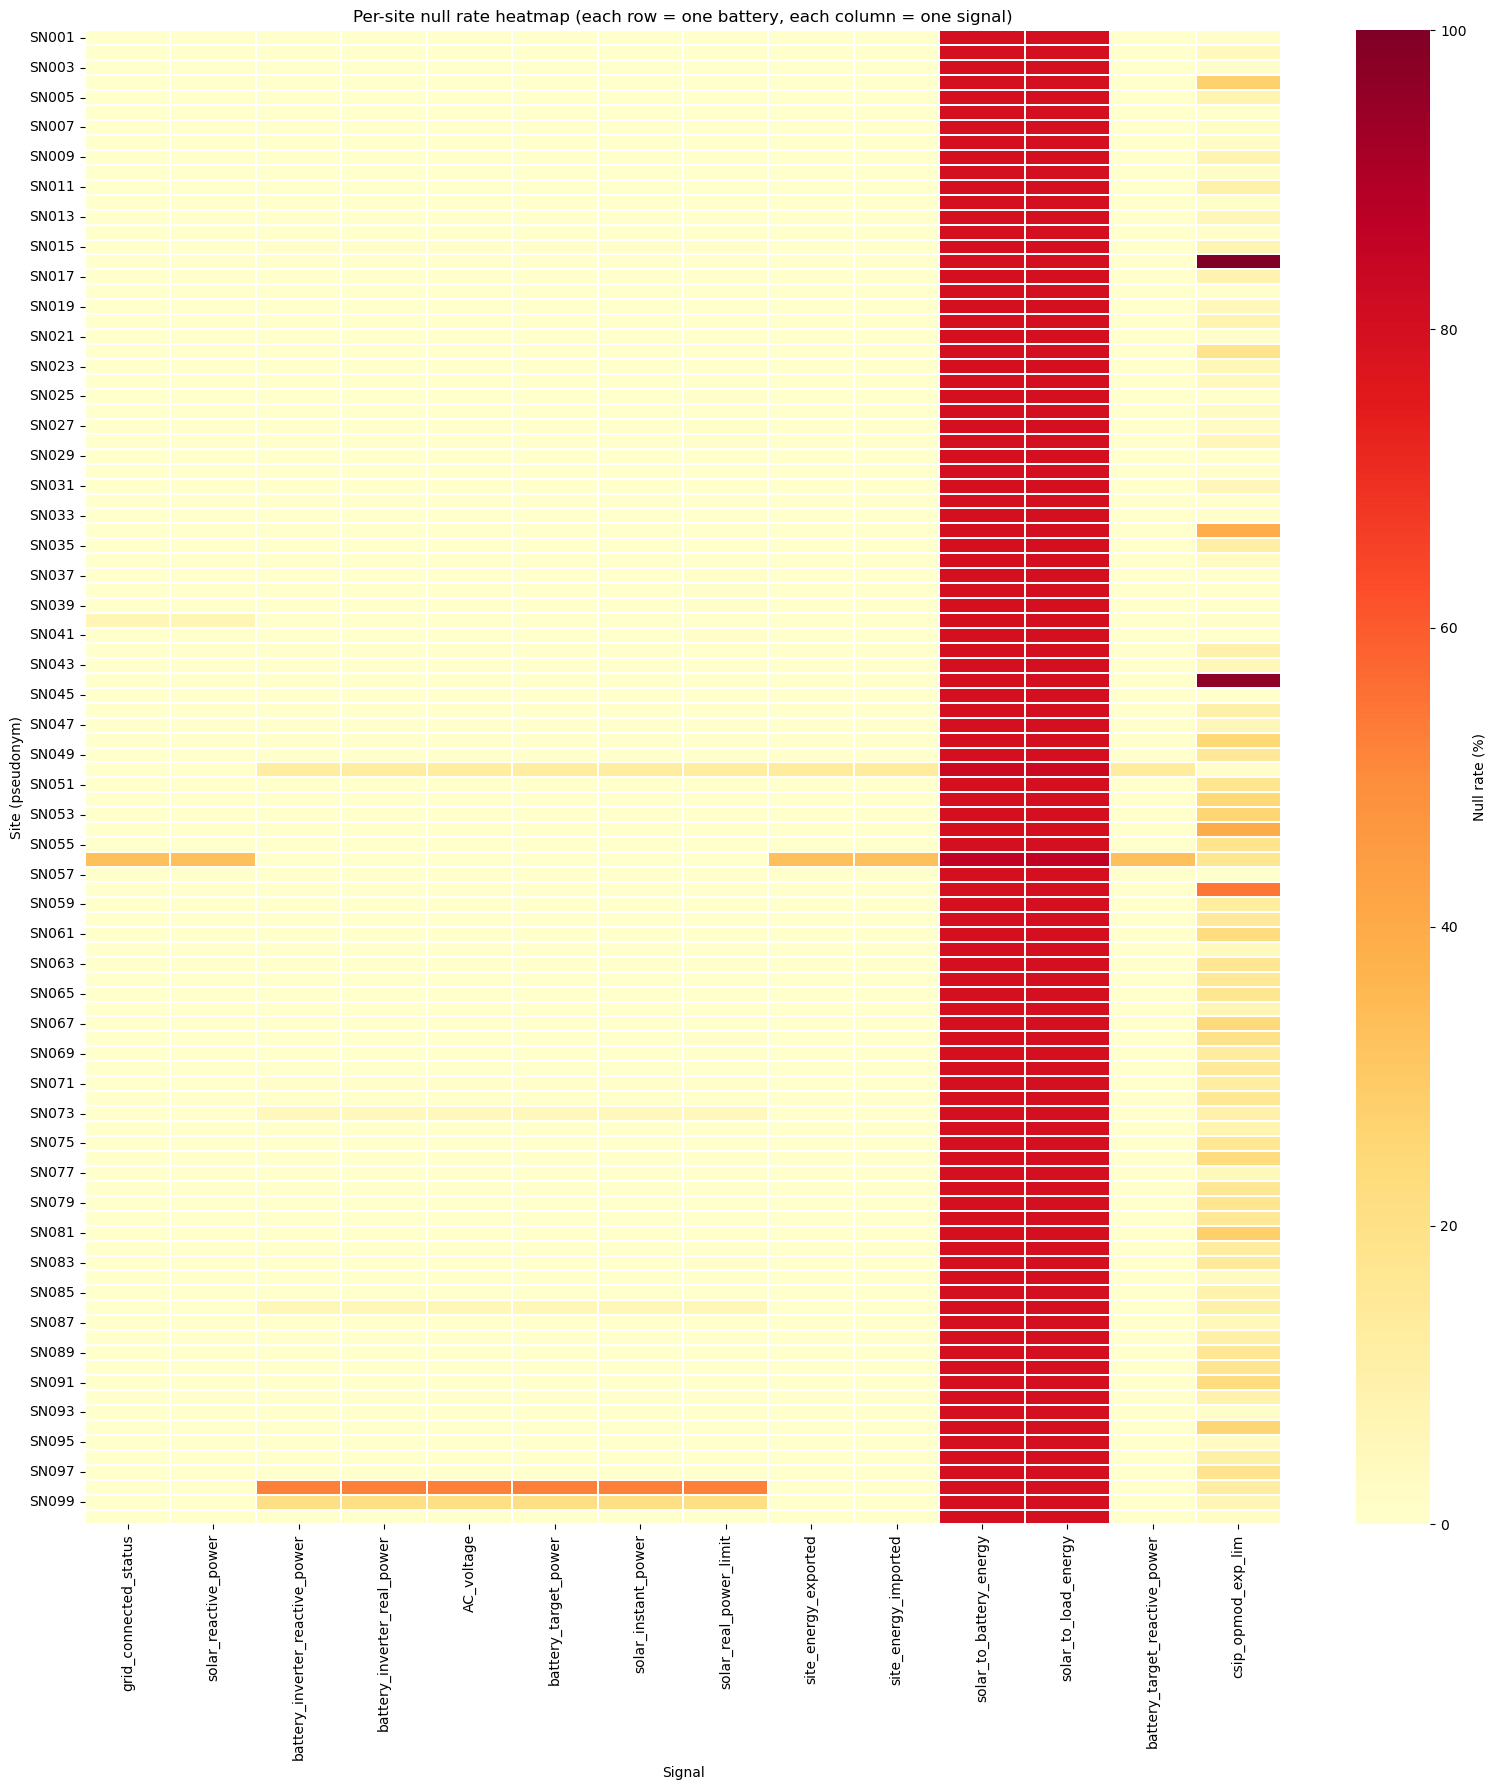

In [46]:
# Heatmap: null rates across columns and sites
null_cols = [c for c in site_quality_df.columns if c.endswith('_null_pct')]
null_heat = site_quality_df[null_cols].copy()
null_heat.columns = [c.replace('_null_pct', '') for c in null_cols]

fig, ax = plt.subplots(figsize=(16, max(8, len(null_heat) * 0.18)))
sns.heatmap(
    null_heat,
    ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=100,
    linewidths=0.1,
    cbar_kws={'label': 'Null rate (%)'}
)
ax.set_title('Per-site null rate heatmap (each row = one battery, each column = one signal)')
ax.set_xlabel('Signal')
ax.set_ylabel('Site (pseudonym)')
plt.tight_layout()
plt.show()

In [ ]:
# Summary stats by region
if 'region' in site_quality_df.columns:
    print("=== Mean completeness and key null rates by region ===")
    key_cols = ['completeness_pct', 'csip_opmod_exp_lim_null_pct',
                'solar_real_power_limit_null_pct', 'pct_voltwatt_zone',
                'pct_above_VW1', 'pct_above_VW2']
    key_cols = [c for c in key_cols if c in site_quality_df.columns]
    print(site_quality_df.groupby('region')[key_cols].mean().round(2).to_string())

=== Mean completeness and key null rates by region ===
        completeness_pct  csip_opmod_exp_lim_null_pct  solar_real_power_limit_null_pct  pct_voltwatt_zone
region                                                                                                   
ausnet            32.530                        9.670                            0.800              0.030
cpu               61.190                        9.200                            0.060              0.470
sapn              83.340                       15.140                            1.830              0.450


## 7. Flags & Export

In [48]:
# Assign pass/flag status on key dimensions
flags = site_quality_df[['completeness_pct']].copy()
if 'region' in site_quality_df.columns:
    flags['region'] = site_quality_df['region']

flags['FLAG_low_completeness']       = site_quality_df['completeness_pct'] < 95
flags['FLAG_has_duplicates']         = site_quality_df['duplicate_ts'] > 0
flags['FLAG_has_large_gaps']         = site_quality_df['n_large_gaps'] > 0
flags['FLAG_csip_mostly_null']       = site_quality_df['csip_opmod_exp_lim_null_pct'] > 50
flags['FLAG_solar_limit_mostly_null']= site_quality_df['solar_real_power_limit_null_pct'] > 80
flags['FLAG_negative_solar']         = site_quality_df['pct_negative_solar'] > 1
flags['FLAG_voltwatt_exposure']   = site_quality_df['pct_above_VW1'] > 5   # >5% time in VW zone
flags['FLAG_over_voltage']        = site_quality_df['pct_above_VW2'] > 1   # >1% time above VW2flags['FLAG_solar_energy_null']      = site_quality_df['solar_to_battery_energy_null_pct'] > 50

flags['n_flags'] = flags[[c for c in flags.columns if c.startswith('FLAG_')]].sum(axis=1)

print("=== Quality flag summary ===")
print(flags[[c for c in flags.columns if c.startswith('FLAG_')]].sum().rename('sites_flagged'))

print("\n=== Sites with 3+ flags ===")
print(flags[flags['n_flags'] >= 3].sort_values('n_flags', ascending=False).to_string())

=== Quality flag summary ===
FLAG_low_completeness           98
FLAG_has_duplicates              0
FLAG_has_large_gaps              6
FLAG_csip_mostly_null            3
FLAG_solar_limit_mostly_null     0
FLAG_negative_solar              0
FLAG_voltwatt_exposure           2
FLAG_over_voltage                0
Name: sites_flagged, dtype: int64

=== Sites with 3+ flags ===
Empty DataFrame
Columns: [completeness_pct, region, FLAG_low_completeness, FLAG_has_duplicates, FLAG_has_large_gaps, FLAG_csip_mostly_null, FLAG_solar_limit_mostly_null, FLAG_negative_solar, FLAG_voltwatt_exposure, FLAG_over_voltage, n_flags]
Index: []


In [ ]:
# Export
# OUTPUT_DIR = Path('.')  # change as needed

# site_quality_df.to_csv(OUTPUT_DIR / 'site_quality_summary.csv')
# flags.to_csv(OUTPUT_DIR / 'site_quality_flags.csv')

# print("Exported:")
# print("  site_quality_summary.csv  — full numeric quality metrics per site")
# print("  site_quality_flags.csv    — pass/fail flags per site")